This notebook showcases how to load work with the Annotation of a section

In [1]:
import sys
sys.path.append('..')
from dharani_functions import DharaniHelper
from matplotlib import pyplot as plt

In [2]:
helper = DharaniHelper(specimennum=2,downsample=7)

In [3]:
secnum = 373

In [4]:
annot = helper.get_annotation(secnum)

In [23]:
thumbnail = helper.get_sectionimage(secnum)

In [5]:
annot.keys()

dict_keys([45, 44, 43, 40, 41, 42, 156, 142, 49, 50, 51, 53, 48, 52, 54, 226, 132, 244, 1026, 243, 503, 253, 158, 143, 236, 229, 134, 13, 31, 32, 33, 34, 35, 36, 17, 131, 14, 15, 16])

Typing the variable name directly visualizes the polygon (as it is a `shapely` geometry) - but the appearance is vertically flipped (origin is at bottom left for shapely)

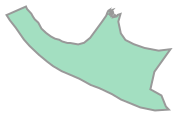

In [14]:
annot[34]

## Extract properties

In [47]:
from annotation_handling import get_properties

In [48]:
props_34=get_properties(annot[34])

In [49]:
props_34

{'pt': (197.34722286456474, 193.68146940470757),
 'area': 6957.108125524464,
 'perimeter': 524.303063207259,
 'numcomp': 1,
 'bbox': (100.05514185653965,
  141.26408610430377,
  264.41315258213035,
  245.74023578600895),
 'aspectratio': 2.4185318570711805,
 'obb': <POLYGON ((291.324 201.671, 121.991 282.899, 88.405 212.884, 257.738 131.656...>,
 'majoraxislength': 187.80729656850895,
 'minoraxislength': 77.65343095209084,
 'maxwidth': 48.921806397931256,
 'orientation': -25.62679718844077}

**Note:**
The values like area, perimeter, lengths, are at the requested resolution (mpp = 2^helper._downsample); 

In this example, we passed downsample=7, meaning mpp=2^7=128, i.e., one pixel unit represents 128 micron. 

The area is in pixel^2, and should convert to sq.micron by multiplying 

In [53]:
area_umsq = props_34['area']*((2**helper._downsample)**2)

In [54]:
area_umsq

113985259.52859282

In [57]:
area_mmsq = area_umsq * (10**-6)

In [58]:
area_mmsq

113.98525952859282

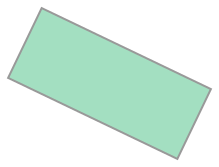

In [36]:
props_34['obb']

In [37]:
from nb_functions import display_shape

This display is at the requested resolution (helper._downsample)

In [38]:
helper._downsample

7

51 -9.665725358957657


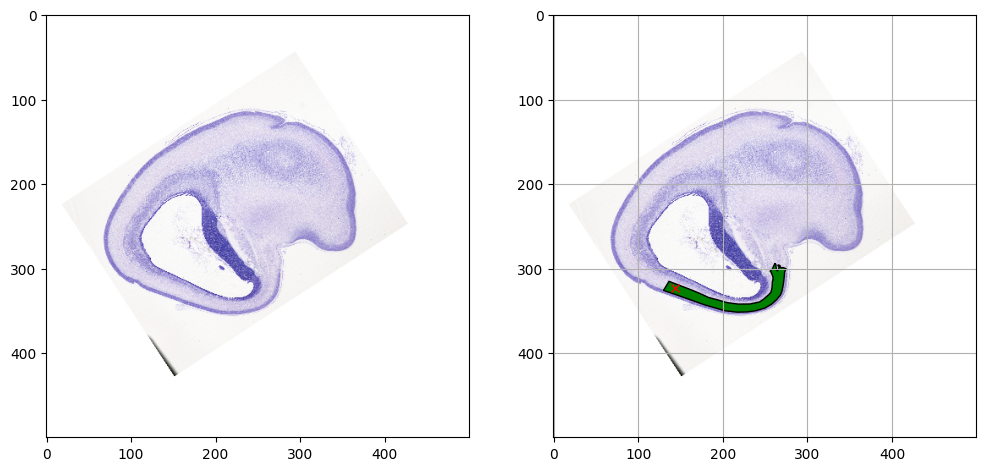

53 1.6688861748740909


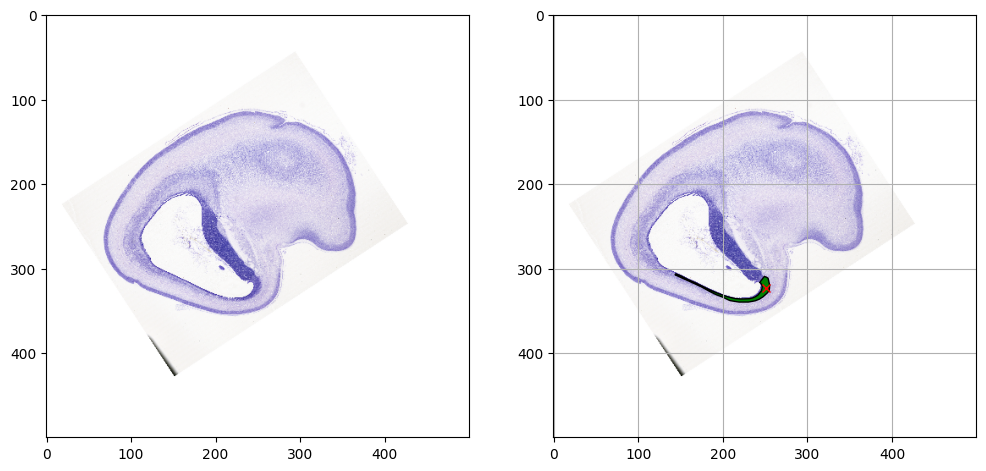

48 -20.647156100798167


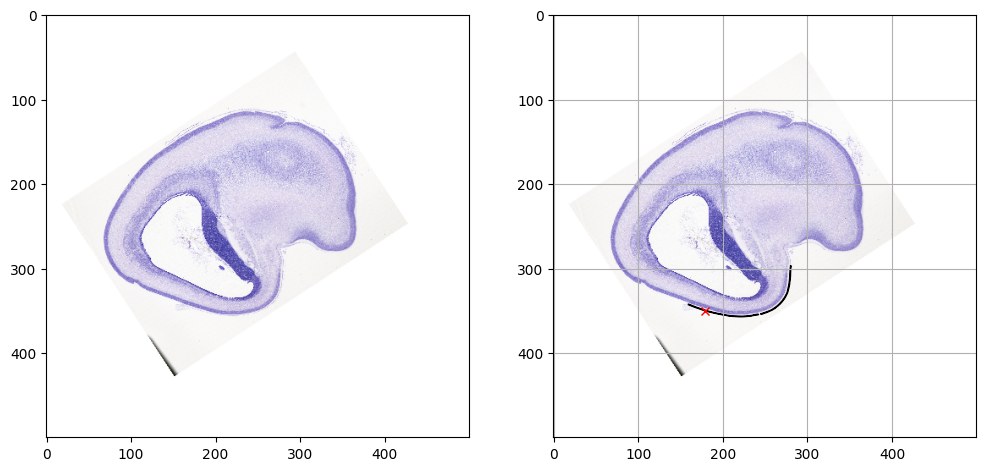

52 -1.5060617596043044


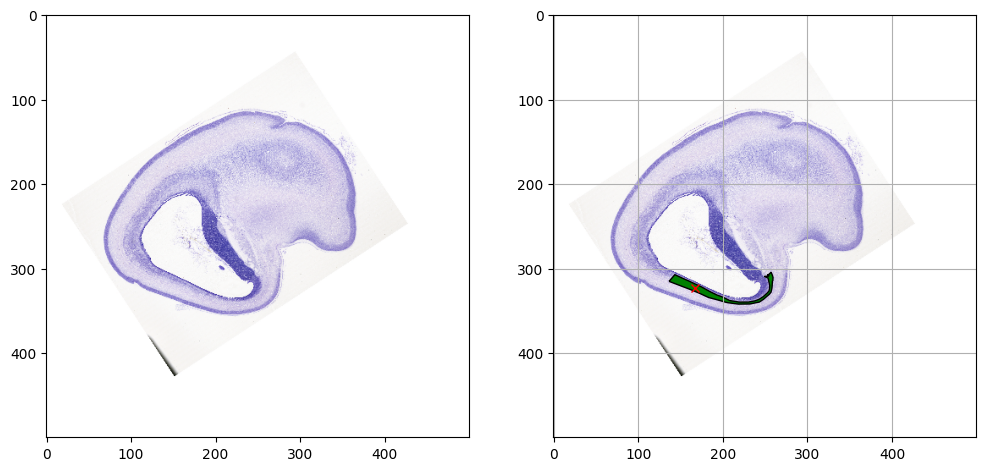

54 6.32576038348957


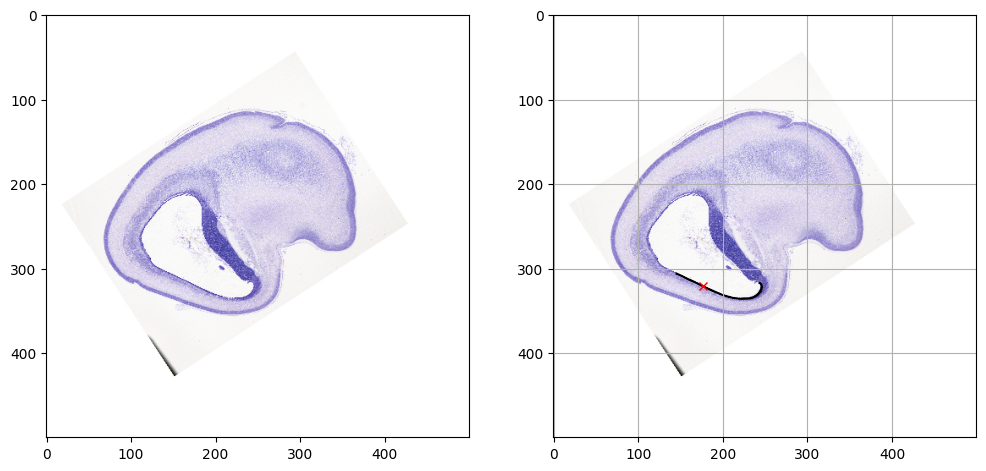

226 56.734009148868815


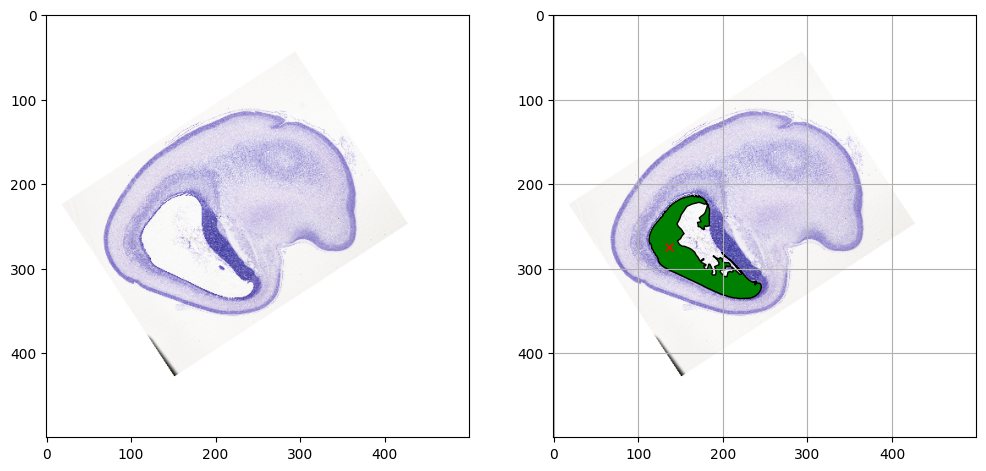

132 -43.11071257203649


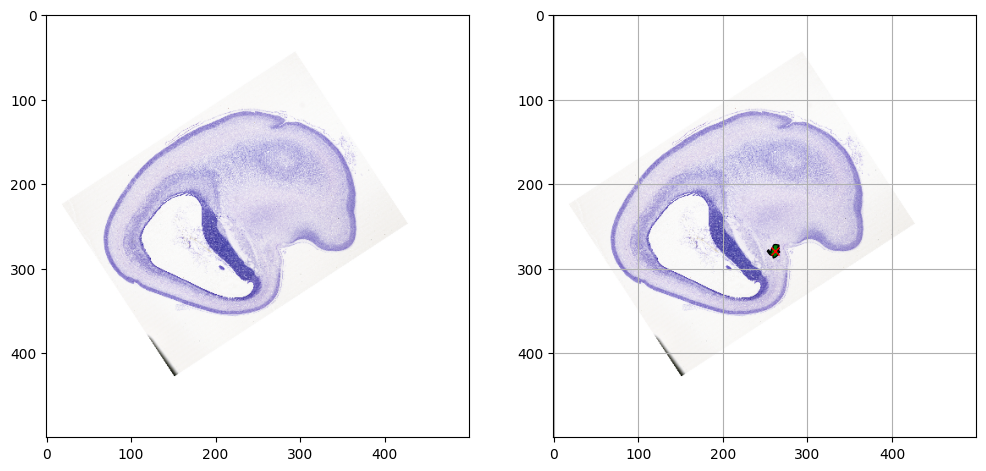

244 51.07723948481946


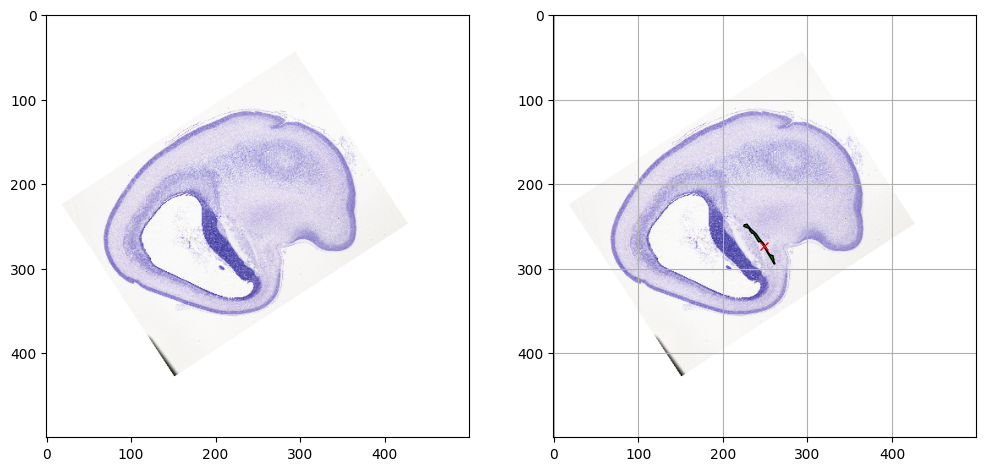

1026 59.95334225258815


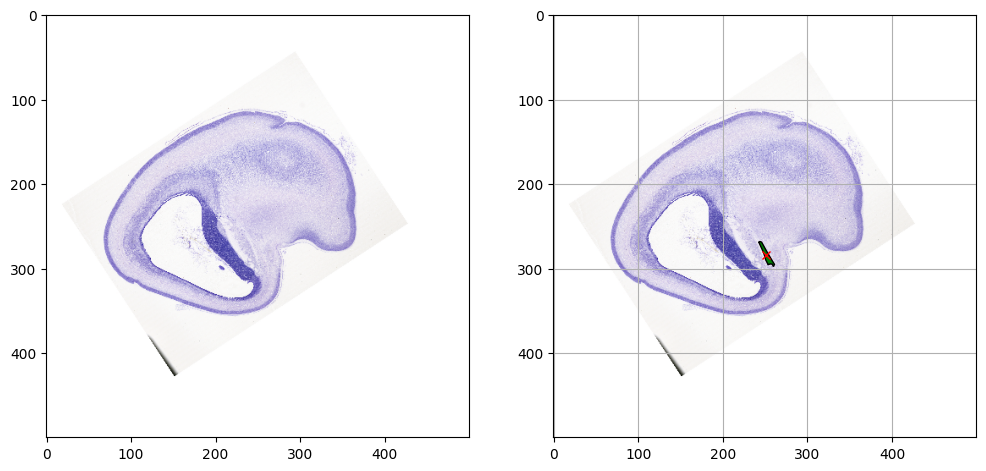

243 66.80193419101379


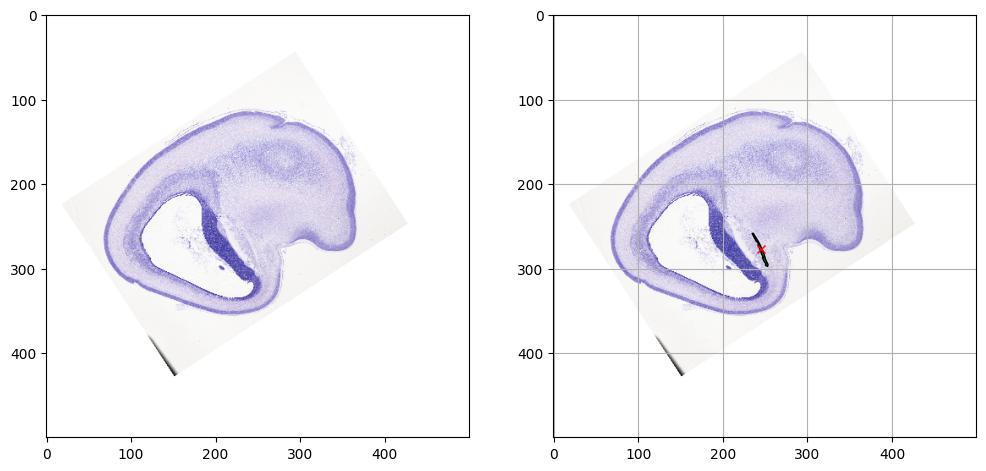

In [60]:
for inspect_id in (51, 53, 48, 52, 54, 226, 132, 244, 1026, 243):
    props = get_properties(annot[inspect_id])
    print(inspect_id, props['orientation'])
    display_shape(thumbnail, annot[inspect_id],'g')
    plt.plot(*props['pt'],'rx')
    plt.show()

## Get adjacency

In [63]:
from annotation_handling import get_adjacency

In [64]:
adj = get_adjacency(annot)

In [66]:
adj.keys()

dict_keys(['touches', 'crosses', 'intersects', 'overlaps'])

In [67]:
adj['touches']

[(45, 54),
 (45, 35),
 (45, 36),
 (44, 34),
 (44, 35),
 (44, 36),
 (43, 51),
 (43, 52),
 (43, 33),
 (43, 34),
 (43, 35),
 (40, 50),
 (41, 50),
 (42, 52),
 (42, 33),
 (42, 34),
 (156, 132),
 (156, 1026),
 (142, 53),
 (142, 143),
 (142, 34),
 (50, 40),
 (50, 41),
 (51, 43),
 (51, 236),
 (51, 134),
 (53, 142),
 (52, 43),
 (52, 42),
 (52, 158),
 (54, 45),
 (54, 158),
 (132, 156),
 (244, 243),
 (244, 503),
 (244, 134),
 (1026, 156),
 (243, 244),
 (503, 244),
 (503, 143),
 (503, 134),
 (158, 52),
 (158, 54),
 (143, 142),
 (143, 503),
 (143, 34),
 (236, 51),
 (134, 51),
 (134, 244),
 (134, 503),
 (134, 15),
 (31, 15),
 (32, 14),
 (32, 15),
 (33, 43),
 (33, 42),
 (33, 34),
 (33, 17),
 (33, 15),
 (33, 16),
 (34, 44),
 (34, 43),
 (34, 42),
 (34, 142),
 (34, 143),
 (34, 33),
 (34, 16),
 (35, 45),
 (35, 44),
 (35, 43),
 (35, 36),
 (36, 45),
 (36, 44),
 (36, 35),
 (17, 33),
 (14, 32),
 (15, 134),
 (15, 31),
 (15, 32),
 (15, 33),
 (16, 33),
 (16, 34)]

In [98]:
adj['crosses']

[]

In [100]:
adj['intersects']

[(45, 44),
 (45, 54),
 (45, 226),
 (45, 35),
 (45, 36),
 (44, 45),
 (44, 43),
 (44, 53),
 (44, 54),
 (44, 34),
 (44, 35),
 (44, 36),
 (43, 44),
 (43, 42),
 (43, 51),
 (43, 53),
 (43, 52),
 (43, 33),
 (43, 34),
 (43, 35),
 (40, 41),
 (40, 49),
 (40, 50),
 (40, 31),
 (41, 40),
 (41, 42),
 (41, 49),
 (41, 50),
 (41, 32),
 (41, 33),
 (42, 43),
 (42, 41),
 (42, 51),
 (42, 52),
 (42, 33),
 (42, 34),
 (156, 50),
 (156, 51),
 (156, 132),
 (156, 244),
 (156, 1026),
 (156, 243),
 (156, 503),
 (156, 253),
 (156, 143),
 (156, 236),
 (156, 134),
 (156, 131),
 (142, 53),
 (142, 52),
 (142, 158),
 (142, 143),
 (142, 236),
 (142, 34),
 (49, 40),
 (49, 41),
 (49, 50),
 (49, 48),
 (49, 134),
 (50, 40),
 (50, 41),
 (50, 156),
 (50, 49),
 (50, 51),
 (50, 134),
 (51, 43),
 (51, 42),
 (51, 156),
 (51, 50),
 (51, 52),
 (51, 244),
 (51, 1026),
 (51, 236),
 (51, 134),
 (53, 44),
 (53, 43),
 (53, 142),
 (53, 52),
 (53, 54),
 (53, 158),
 (48, 49),
 (48, 134),
 (52, 43),
 (52, 42),
 (52, 142),
 (52, 51),
 (52, 53

In [99]:
adj['overlaps']

[(45, 44),
 (45, 226),
 (44, 45),
 (44, 43),
 (44, 53),
 (44, 54),
 (43, 44),
 (43, 42),
 (43, 53),
 (40, 41),
 (40, 49),
 (40, 31),
 (41, 40),
 (41, 42),
 (41, 49),
 (41, 32),
 (41, 33),
 (42, 43),
 (42, 41),
 (42, 51),
 (156, 50),
 (156, 51),
 (156, 244),
 (156, 243),
 (156, 503),
 (156, 253),
 (156, 143),
 (156, 236),
 (156, 134),
 (156, 131),
 (142, 52),
 (142, 158),
 (142, 236),
 (49, 40),
 (49, 41),
 (49, 50),
 (49, 48),
 (49, 134),
 (50, 156),
 (50, 49),
 (50, 51),
 (50, 134),
 (51, 42),
 (51, 156),
 (51, 50),
 (51, 52),
 (51, 244),
 (51, 1026),
 (53, 44),
 (53, 43),
 (53, 52),
 (53, 54),
 (53, 158),
 (48, 49),
 (48, 134),
 (52, 142),
 (52, 51),
 (52, 53),
 (52, 236),
 (54, 44),
 (54, 53),
 (54, 226),
 (226, 45),
 (226, 54),
 (226, 158),
 (226, 229),
 (226, 36),
 (132, 244),
 (132, 503),
 (132, 253),
 (132, 134),
 (244, 156),
 (244, 51),
 (244, 132),
 (244, 1026),
 (244, 143),
 (1026, 51),
 (1026, 244),
 (1026, 243),
 (243, 156),
 (243, 1026),
 (243, 143),
 (503, 156),
 (503, 13

In [72]:
import networkx as nx

In [109]:
gr_touch = nx.DiGraph(adj['touches'])

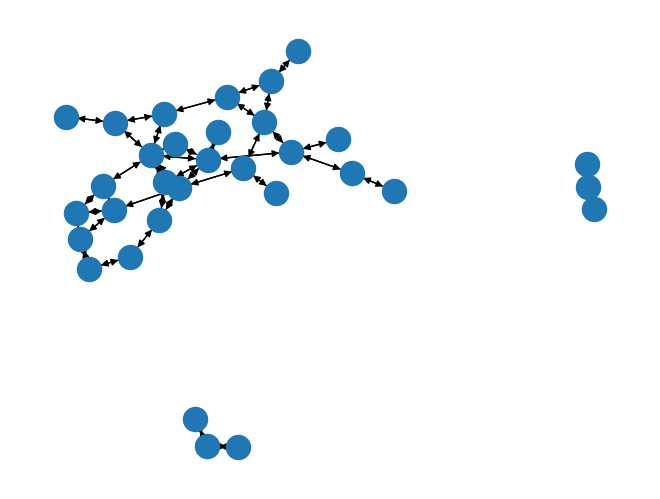

In [110]:
nx.draw(gr_touch)

In [111]:
gr=nx.DiGraph(adj['touches'] + adj['crosses']+adj['intersects']+adj['overlaps'], )

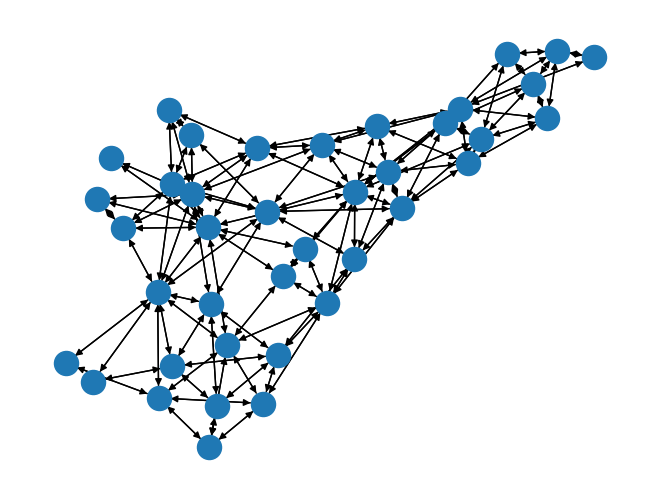

In [112]:
nx.draw(gr)

In [116]:
list(nx.algorithms.components.weakly_connected_components(gr_touch))

[{14,
  15,
  16,
  17,
  31,
  32,
  33,
  34,
  35,
  36,
  42,
  43,
  44,
  45,
  51,
  52,
  53,
  54,
  134,
  142,
  143,
  158,
  236,
  243,
  244,
  503},
 {40, 41, 50},
 {132, 156, 1026}]

In [119]:
list(gr_touch.neighbors(132))

[156]

In [120]:
list(gr.neighbors(132))

[156, 244, 503, 253, 134]

132


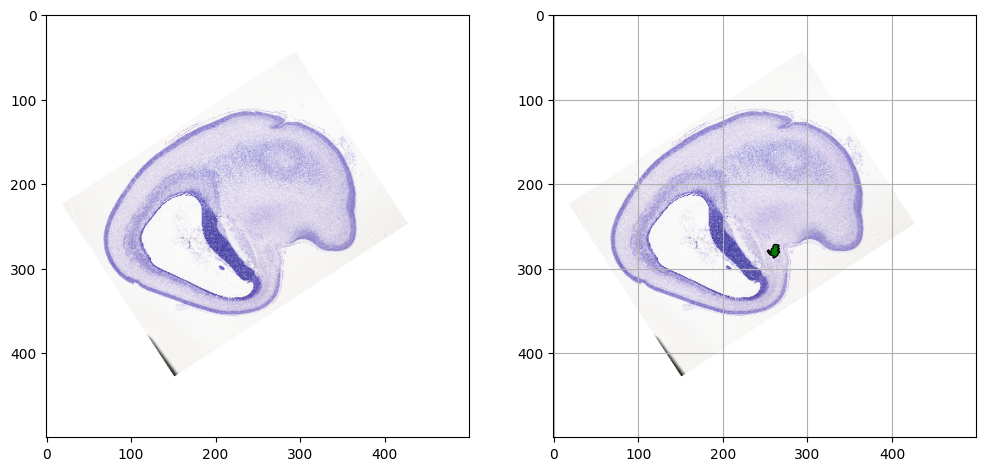

156


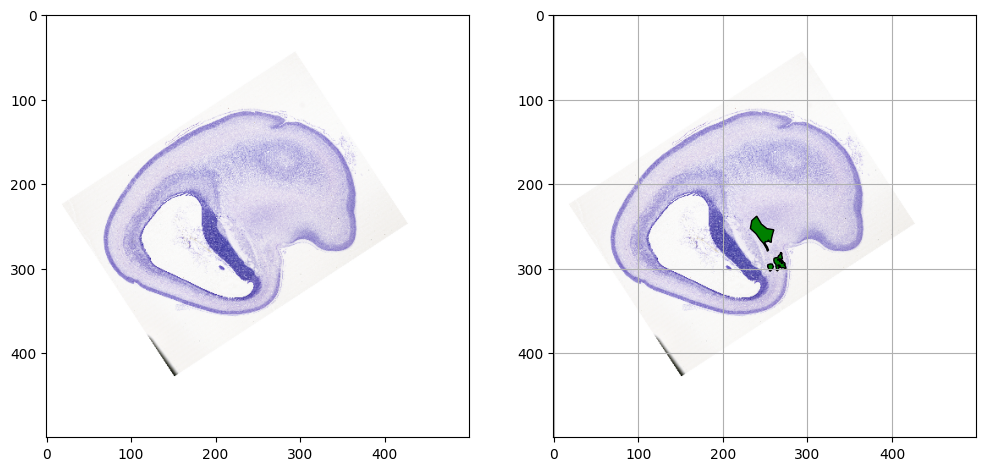

1026


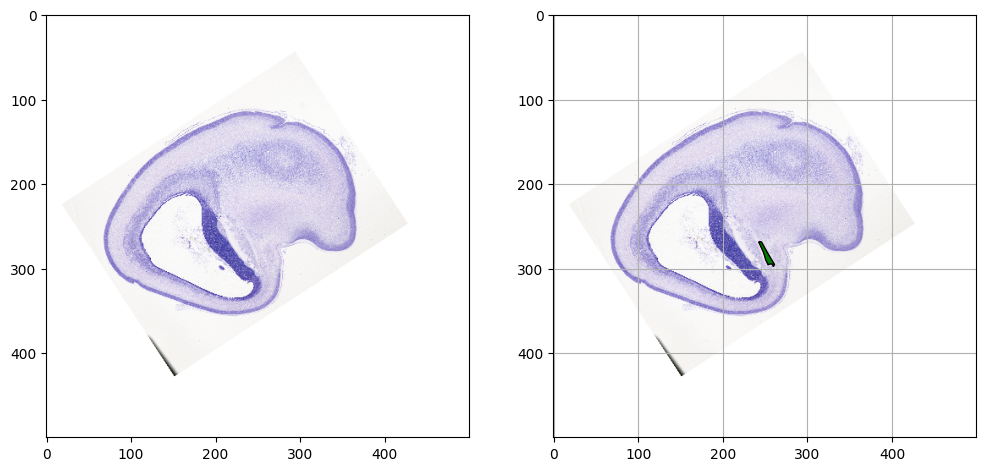

In [122]:
for inspect_id in (132, 156, 1026):
    print(inspect_id)
    display_shape(thumbnail, annot[inspect_id],'g')
    plt.show()